# Plot de Captura Real e Virtual

Este notebook seleciona a captura diretamente do que ja foi exportado em `output/robot_emotions_virtual_imu_cal`.
O plot de cima mostra o IMU real e o de baixo mostra o IMU virtual.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
from IPython.display import display

cwd = Path.cwd().resolve()
candidate_roots = [cwd, *cwd.parents]
PROJECT_ROOT = None
for candidate in candidate_roots:
    if (candidate / "pose_module").exists() and (candidate / "output").exists():
        PROJECT_ROOT = candidate
        break

if PROJECT_ROOT is None:
    raise RuntimeError("Nao encontrei a raiz do projeto. Abra o notebook dentro do repo IMUGPT.")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from evaluation.utils import (
    build_exported_capture_table,
    plot_real_virtual_capture,
)

plt.style.use("seaborn-v0_8-whitegrid")

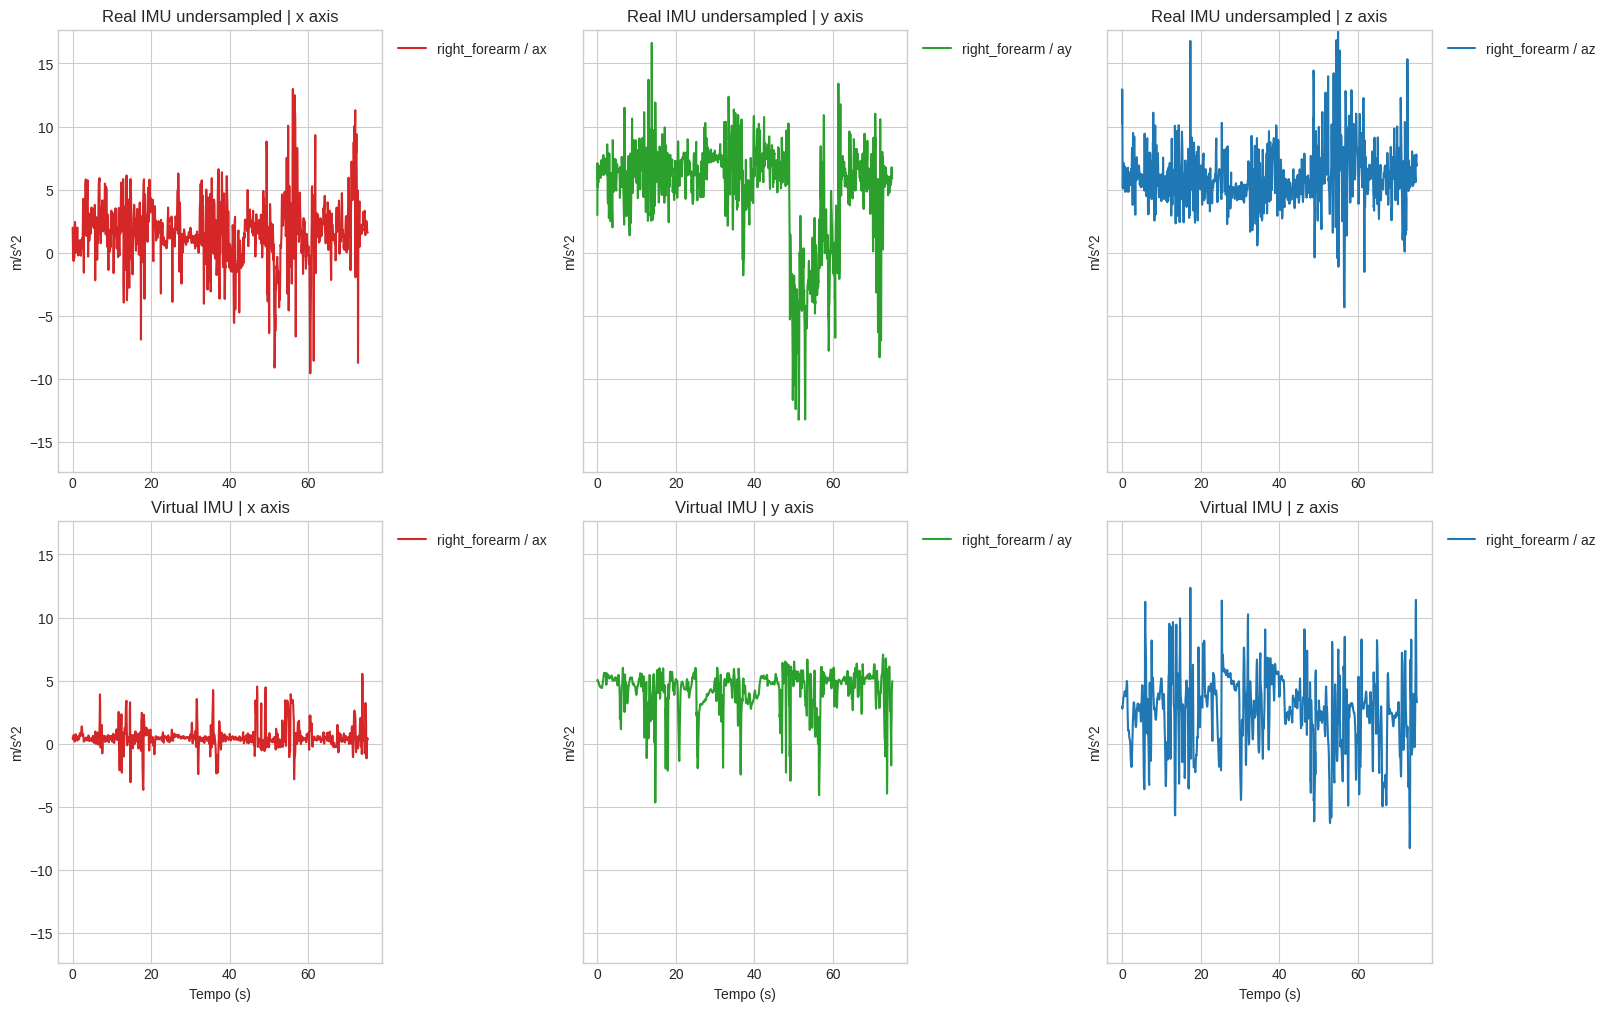

,clip_id,domain,user_id,tag_number,take_id,emotion,modality,stimulus,stimulus_details,protocol_tag_10ms,protocol_tag_30ms,signal_group,undersampled_real_to_virtual,selected_sensors,real_frames,real_plot_frames,virtual_frames,real_original_frequency_hz,real_plot_frequency_hz,virtual_frequency_hz,real_vs_virtual_mean_time_error_ms,real_vs_virtual_max_time_error_ms,frame_aligned_available,frame_aligned_frames
0,robot_emotions_10ms_u05_tag10,10ms,5,10,NaN,Happiness,Sitting,Autobiographical recall,Ask the participant to recall a happy episode/...,10,3,acc,True,right_forearm,8334,1503,1503,500.274809,29.966164,29.966164,5.242198,151.367188,False,None


In [2]:
OUTPUT_ROOT = PROJECT_ROOT / "output" / "robot_emotions_virtual_imu_v2_all_dataset"
CAPTURES_DF = build_exported_capture_table(OUTPUT_ROOT)

# Selecao da captura
DOMAIN = "10ms"
USER_ID = 5
TAG_NUMBER = 10
TAKE_ID = None

# Parametros do plot
SIGNAL_GROUP = "acc"  # "acc" ou "gyro"
SENSOR_NAMES = ["right_forearm"]  # None para todos os sensores
TIME_RANGE_SEC = None  # Exemplo: (0, 20)
FIGSIZE = (16, 10)
LINE_WIDTH = 1.5
UNDERSAMPLE_REAL_TO_VIRTUAL = True

summary_df, fig = plot_real_virtual_capture(
    CAPTURES_DF,
    domain=DOMAIN,
    user_id=USER_ID,
    tag_number=TAG_NUMBER,
    take_id=TAKE_ID,
    signal_group=SIGNAL_GROUP,
    sensor_names=SENSOR_NAMES,
    time_range_sec=TIME_RANGE_SEC,
    figsize=FIGSIZE,
    line_width=LINE_WIDTH,
    undersample_real_to_virtual=UNDERSAMPLE_REAL_TO_VIRTUAL,
    show=True,
)

display(summary_df)